In [1]:
from bluemath_tk.core.plotting.base_plotting import DefaultStaticPlotting
from utils.swan_utils import read_adcirc_grd
from utils.CarolinasParamWrapper_swan import CarolinasParaMWrapper
import numpy as np
import cartopy.crs as ccrs
import xarray as xr
import pandas as pd

* Data access can be requested to bluemath@unican.es
You can update any path or add new paths with the update_paths function, from bluemath_tk.config.paths.
Example: update_paths({'SHYTCWAVES_COEFS': '/new/path/to/data'})


Using Esri World Imagery (ArcGIS):
- Free for public and non-commercial use
- Commercial use allowed under Esri terms of service
- Attribution required: 'Tiles © Esri — Sources: Esri, Earthstar Geographics, CNES/Airbus DS, USDA, USGS, AeroGRID, IGN, and the GIS User Community'
- Max zoom ~19


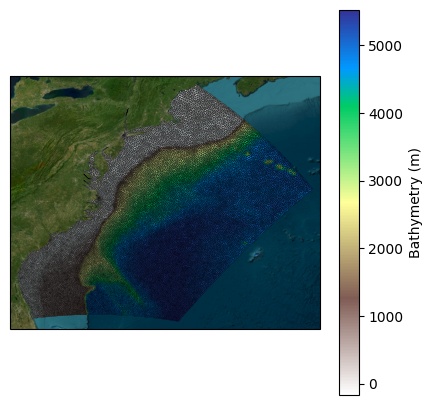

In [2]:
plot = DefaultStaticPlotting()
Nodes_calc, Elmts_calc, lines_calc = read_adcirc_grd("templates/fort.14")

facecolor = np.mean(Nodes_calc[:, 3][Elmts_calc[:, 2:5].astype(int)], axis=1)

fig, ax = plot.get_subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    figsize=(5, 5),
)

pcl = ax.tripcolor(
    Nodes_calc[:, 1],
    Nodes_calc[:, 2],
    Elmts_calc[:, 2:5],
    facecolor,
    edgecolors="k",
    linewidth=0.2,
    shading="flat",
    cmap="terrain_r",
)
colorbar = fig.colorbar(pcl, ax=ax, orientation="vertical")
colorbar.set_label("Bathymetry (m)")
margim = 0.5
plot.plot_satellite(
        ax=ax,
        source="arcgis",
        area=[
            Nodes_calc[:, 1].min() - margim,
            Nodes_calc[:, 1].max() + margim,
            Nodes_calc[:, 2].min() - margim,
            Nodes_calc[:, 2].max() + margim,
        ],)

In [3]:
dm = 16384

lon_min = Nodes_calc[:, 1].min()
lon_max = Nodes_calc[:, 1].max()
lat_min = Nodes_calc[:, 2].min()
lat_max = Nodes_calc[:, 2].max()

lat_ref = 0.5 * (lat_min + lat_max)

min_dy = dm / 111320.0
min_dx = dm / (111320.0 * np.cos(np.deg2rad(lat_ref)))

lon_grid = np.arange(lon_min, lon_max + min_dx, min_dx)
lat_grid = np.arange(lat_min, lat_max + min_dy, min_dy)

dlon = lon_grid[1] - lon_grid[0]
dlat = lat_grid[1] - lat_grid[0]
nx = len(lon_grid) - 1
ny = len(lat_grid) - 1

In [4]:
Tracks = xr.open_dataset("outputs/syntetic_tracks_7r.nc")
Tracks

<xarray.Dataset> Size: 304MB
Dimensions:  (storm: 13184, time: 958)
Coordinates:
  * time     (time) int64 8kB 0 1 2 3 4 5 6 7 ... 951 952 953 954 955 956 957
    date     (storm) <U19 1MB ...
Dimensions without coordinates: storm
Data variables:
    lat      (storm, time) float64 101MB ...
    lon      (storm, time) float64 101MB ...
    pmin     (storm, time) float64 101MB ...
Attributes:
    description:  Synthetic TC tracks

In [5]:
df = pd.read_csv("outputs/selected_cases_MDA.csv", header=None)
selected_cases = df.iloc[:, 0].tolist()
print(f"{len(selected_cases)} cases to run.")
print(selected_cases)

4000 cases to run.
[5464, 3822, 2892, 7105, 9715, 4104, 2932, 5473, 6089, 9076, 5196, 763, 3267, 11364, 13175, 564, 6057, 11772, 6373, 9270, 9045, 5709, 8909, 873, 4110, 10037, 11050, 9314, 11011, 11542, 4305, 4743, 6715, 8166, 12395, 5968, 6084, 8051, 10028, 5714, 3981, 407, 6467, 10035, 674, 12783, 10885, 2651, 13141, 11919, 9802, 6349, 2868, 6427, 3508, 6648, 495, 522, 12011, 445, 8794, 4443, 12571, 10284, 11121, 11152, 9236, 3427, 7435, 2727, 2906, 11562, 458, 5469, 11399, 6714, 10839, 5451, 12381, 6044, 1548, 5993, 4549, 3215, 11421, 4346, 11476, 3275, 946, 11792, 7215, 5134, 32, 10261, 6301, 9331, 3364, 7864, 5193, 8692, 10561, 12357, 9223, 4783, 4119, 10879, 9765, 11945, 8780, 10996, 13139, 5012, 3592, 859, 8825, 2719, 4032, 10899, 851, 907, 12736, 7083, 9710, 7367, 2566, 13177, 8169, 8609, 5471, 5837, 10680, 3295, 8835, 8059, 10805, 592, 2941, 12296, 5352, 1423, 8731, 13152, 12849, 4642, 7990, 3019, 395, 4676, 1509, 4669, 6419, 9773, 10270, 9748, 2198, 2330, 1011, 11091, 13158,

In [6]:
templates_dir = "templates"
output_dir =  "cases/metamodel_added"

time_step = 1 # hours

fixed_parameters = {
    "time_step": 3600 * time_step,
    "time_step_comp":900,
    "lon_grid":lon_grid,
    "lat_grid":lat_grid,
    "lon_min":lon_min,
    "lat_min":lat_min,
    "Tracks":Tracks,
    "dlon":dlon,
    "dlat":dlat,
    "nx":nx,
    "ny":ny,
    "additional_time_end":50 * 60 * 60,
    "additional_time_init":12 * 60 * 60,
}

metamodel_parameters = {
    "index": selected_cases[2000:3000],
}

swan_wrapper_param = CarolinasParaMWrapper(
    templates_dir=templates_dir,
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
)

swan_wrapper_param.build_cases(mode="one_by_one", cases_name_format=lambda ctx: f"{Tracks.storm.values[ctx.get('index')]}")

2026-01-27 17:38:53,048 - CarolinasParaMWrapper - WARNING - Parameter index is not in the default_parameters
